# Instagram Reels — Analýza algoritmického doporučování
## Výzkum expozice nevhodného obsahu u nezletilých uživatelů
---

**Cíl výzkumu:** Zjistit, zda algoritmus Instagram Reels cíleně doporučuje nevhodný obsah (gambling, adult entertainment, shock content aj.) nezletilým uživatelům, kteří tento obsah dříve aktivně vyhledávali.

**Metodologie:** Sock-puppet audit se dvěma syntetickými profily:
- **User 1** (ig.user1) — profil se zájmy o nevhodný obsah (gambling, adult entertainment, dark humor, crime…)
- **User 2** (ig.user2) — kontrolní profil s neutrálními zájmy (sport, vaření, cyklistika, ekologie…)

**Klíčová proměnná:** Oba profily deklarovaly věk odpovídající roku narození **2008**, přičemž skutečný modelový věk odpovídá roku **2012** (tj. 13–14 let). Tato diskrepance je záměrná — testuje, jak Instagram reaguje na nezletilého uživatele hledajícího potenciálně škodlivý obsah.

# 1. KNIHOVNY A KONFIGURACE

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
from datetime import datetime
from math import pi
import warnings
warnings.filterwarnings('ignore')

from IPython.display import display, Markdown

# === Barevná paleta ===
COLORS = {
    'topic_match': '#e74c3c',       # červená — obsah matchující hledaná témata
    'random':      '#95a5a6',       # šedá — náhodný/generický obsah
    'primary':     '#1a1a2e',
    'secondary':   '#16213e',
    'user1':       '#e74c3c',       # User1 — nevhodný obsah
    'user2':       '#2ecc71',       # User2 — neutrální obsah
    'watch':       '#3498db',
    'like':        '#f39c12',
    'bookmark':    '#9b59b6',
    'funnel':      ['#3498db', '#2ecc71', '#f39c12', '#9b59b6']
}

# === Nastavení grafů ===
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (14, 6),
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'axes.titleweight': 'bold',
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False
})

print("✓ Knihovny načteny")

✓ Knihovny načteny


# 2. NAČTENÍ DAT

In [2]:
# === Načtení obou datasetů ===
df1 = pd.read_csv("session_ig.csv")
df2 = pd.read_csv("session_ig_2.csv")

# Přidání identifikátoru uživatele
df1['user_label'] = 'User 1 (nevhodný obsah)'
df2['user_label'] = 'User 2 (neutrální obsah)'

# Přidání pořadového čísla interakce
df1['interaction_number'] = range(1, len(df1) + 1)
df2['interaction_number'] = range(1, len(df2) + 1)

# Extrakce seznamu hledaných témat
df1['interest_topics'] = df1['topic'].apply(lambda x: [t.strip() for t in x.split(',')])
df2['interest_topics'] = df2['topic'].apply(lambda x: [t.strip() for t in x.split(',')])

# === Topic match flag ===
# predicted_topic != 'random' znamená, že algoritmus přiřadil konkrétní téma z hledaných zájmů
df1['is_topic_match'] = df1['predicted_topic'] != 'random'
df2['is_topic_match'] = df2['predicted_topic'] != 'random'

# Sloučený dataset pro společné vizualizace
df_all = pd.concat([df1, df2], ignore_index=True)

print(f"✓ User 1 (nevhodný obsah): {len(df1):,} záznamů")
print(f"✓ User 2 (neutrální obsah): {len(df2):,} záznamů")
print(f"✓ Celkem: {len(df_all):,} záznamů")
print(f"\nUser 1 — hledaná témata: {df1['interest_topics'].iloc[0]}")
print(f"User 2 — hledaná témata: {df2['interest_topics'].iloc[0]}")
display(df_all.head(3))

✓ User 1 (nevhodný obsah): 803 záznamů
✓ User 2 (neutrální obsah): 759 záznamů
✓ Celkem: 1,562 záznamů

User 1 — hledaná témata: ['gambling', 'casino_lifestyle', 'adult_entertainment', 'taboo_topics', 'dark_humor', 'shock_content', 'crime_and_cartels', 'prison_stories', 'street_fights', 'gang_culture', 'nightlife_and_clubs', 'sparta', 'extreme_pranks', 'controversial_interviews']
User 2 — hledaná témata: ['football', 'gym', 'home_cooking', 'healthy_recipes', 'international_cuisine', 'road_cycling', 'cycling_routes', 'bike_gear', 'sustainability', 'eco_lifestyle', 'tour_de_france', 'renewable_energy', 'travel', 'healthy_lifestyle']


,video_url,video_id,video_author,video_description,video_time_duration,video_action_watch,video_action_like,video_action_bookmark,user_email,topic,gender,country_code,date_of_birth,predicted_topic,user_label,interaction_number,interest_topics,is_topic_match
0,https://www.instagram.com/reel/DThcB2-APSj/,DThcB2-APSj,itsparultime and paruldavlog,Reel by itsparultime. Double-tap to play or pa...,11,False,False,False,ig.user1@seznam.cz,"gambling, casino_lifestyle, adult_entertainmen...",male,cz,08.03.2008,random,User 1 (nevhodný obsah),1,"[gambling, casino_lifestyle, adult_entertainme...",False
1,https://www.instagram.com/reel/DTcVXMXCC9P/,DTcVXMXCC9P,vinnyaroradhoopar,Professional fun starter ..‍♀️ …,26,True,True,False,ig.user1@seznam.cz,"gambling, casino_lifestyle, adult_entertainmen...",male,cz,08.03.2008,random,User 1 (nevhodný obsah),2,"[gambling, casino_lifestyle, adult_entertainme...",False
2,https://www.instagram.com/reel/DVeHNj_gZyM/,DVeHNj_gZyM,nawabzadidelhi,Science confirms: 100% of tears are cured by a...,23,False,False,False,ig.user1@seznam.cz,"gambling, casino_lifestyle, adult_entertainmen...",male,cz,08.03.2008,random,User 1 (nevhodný obsah),3,"[gambling, casino_lifestyle, adult_entertainme...",False


# 3. PŘÍPRAVA DAT A ZÁKLADNÍ STATISTIKY

In [3]:
# === Souhrnné statistiky pro oba uživatele ===
def user_summary(df, label):
    n = len(df)
    match_n = df['is_topic_match'].sum()
    match_pct = match_n / n * 100
    watch_rate = df['video_action_watch'].mean() * 100
    like_rate = df['video_action_like'].mean() * 100
    bookmark_rate = df['video_action_bookmark'].mean() * 100
    avg_duration = df['video_time_duration'].mean()
    
    topics_found = df[df['is_topic_match']]['predicted_topic'].unique().tolist()
    
    return {
        'Uživatel': label,
        'Počet videí': n,
        'Topic match': f"{match_n} ({match_pct:.2f}%)",
        'Watch rate': f"{watch_rate:.1f}%",
        'Like rate': f"{like_rate:.1f}%",
        'Bookmark rate': f"{bookmark_rate:.1f}%",
        'Průměrná délka videa (s)': f"{avg_duration:.1f}",
        'Nalezená témata': ', '.join(topics_found) if topics_found else '—'
    }

summary = pd.DataFrame([
    user_summary(df1, 'User 1 — nevhodný obsah'),
    user_summary(df2, 'User 2 — neutrální obsah')
]).set_index('Uživatel')

display(summary.T)

Uživatel,User 1 — nevhodný obsah,User 2 — neutrální obsah
Počet videí,803,759
Topic match,2 (0.25%),11 (1.45%)
Watch rate,57.9%,63.6%
Like rate,40.6%,29.8%
Bookmark rate,0.0%,0.1%
Průměrná délka videa (s),10.8,8.3
Nalezená témata,"gambling, taboo_topics","home_cooking, healthy_lifestyle, healthy_recipes"


---
# 4. ANALÝZA VĚKOVÉ DISKREPANCE
---

Oba syntetické profily deklarovaly datum narození odpovídající roku **2008** (deklarovaný věk ~18 let).  
Skutečný modelový věk odpovídá roku **2012** (reálný věk **13–14 let**).

Tato sekce vizualizuje nesoulad a jeho implikace pro ochranu nezletilých na platformě.

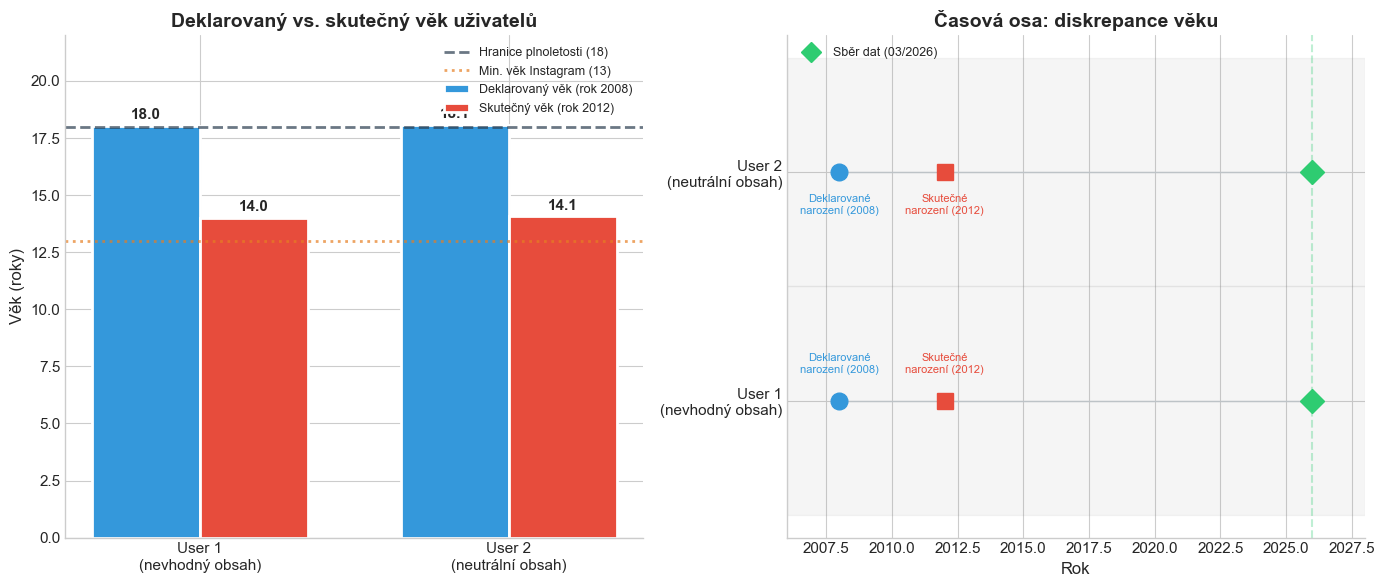


⚠️  Oba uživatelé předstírají věk ~18 let, ale modelově jim je 13–14 let.
   Instagram umožňuje registraci od 13 let, ale přístup k nevhodnému obsahu by měl být omezen.


In [4]:
from datetime import date

# === Data o věku ===
users_age = []
for label, df, color in [('User 1\n(nevhodný obsah)', df1, COLORS['user1']), 
                           ('User 2\n(neutrální obsah)', df2, COLORS['user2'])]:
    dob_str = df['date_of_birth'].iloc[0]
    dob = datetime.strptime(dob_str, '%d.%m.%Y')
    declared_age = (datetime(2026, 3, 16) - dob).days / 365.25
    real_dob = dob.replace(year=2012)
    real_age = (datetime(2026, 3, 16) - real_dob).days / 365.25
    users_age.append({
        'label': label,
        'declared_dob': dob_str,
        'declared_age': declared_age,
        'real_age': real_age,
        'color': color
    })

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Panel 1: Srovnání deklarovaného vs reálného věku ---
ax = axes[0]
x = np.arange(len(users_age))
width = 0.35

bars_declared = ax.bar(x - width/2, [u['declared_age'] for u in users_age], width,
                       label='Deklarovaný věk (rok 2008)', color='#3498db', edgecolor='white', linewidth=2)
bars_real = ax.bar(x + width/2, [u['real_age'] for u in users_age], width,
                   label='Skutečný věk (rok 2012)', color='#e74c3c', edgecolor='white', linewidth=2)

ax.axhline(y=18, color='#2c3e50', linestyle='--', linewidth=2, alpha=0.7, label='Hranice plnoletosti (18)')
ax.axhline(y=13, color='#e67e22', linestyle=':', linewidth=2, alpha=0.7, label='Min. věk Instagram (13)')

for bars in [bars_declared, bars_real]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.3, f'{h:.1f}',
                ha='center', fontweight='bold', fontsize=11)

ax.set_xticks(x)
ax.set_xticklabels([u['label'] for u in users_age])
ax.set_ylabel('Věk (roky)')
ax.set_title('Deklarovaný vs. skutečný věk uživatelů', fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.set_ylim(0, 22)

# --- Panel 2: Timeline vizualizace ---
ax2 = axes[1]

years = list(range(2008, 2027))
ax2.axhspan(-0.5, 0.5, alpha=0.08, color='gray')
ax2.axhspan(0.5, 1.5, alpha=0.08, color='gray')

for i, u in enumerate(users_age):
    # Deklarované narození
    ax2.plot(2008, i, 'o', color='#3498db', markersize=12, zorder=5)
    ax2.annotate('Deklarované\nnarození (2008)', (2008, i), textcoords="offset points",
                xytext=(0, 20 if i == 0 else -30), ha='center', fontsize=8, color='#3498db')
    
    # Skutečné narození
    ax2.plot(2012, i, 's', color='#e74c3c', markersize=12, zorder=5)
    ax2.annotate('Skutečné\nnarození (2012)', (2012, i), textcoords="offset points",
                xytext=(0, 20 if i == 0 else -30), ha='center', fontsize=8, color='#e74c3c')
    
    # Sběr dat
    ax2.plot(2026, i, 'D', color='#2ecc71', markersize=12, zorder=5)
    
    # Spojnice
    ax2.plot([2008, 2026], [i, i], '-', color='#bdc3c7', linewidth=1, zorder=1)

ax2.plot([], [], 'D', color='#2ecc71', markersize=10, label='Sběr dat (03/2026)')
ax2.axvline(x=2026, color='#2ecc71', linestyle='--', alpha=0.3)

ax2.set_yticks([0, 1])
ax2.set_yticklabels([u['label'] for u in users_age])
ax2.set_xlabel('Rok')
ax2.set_title('Časová osa: diskrepance věku', fontweight='bold')
ax2.legend(loc='upper left', fontsize=9)
ax2.set_xlim(2006, 2028)

plt.tight_layout()
plt.savefig('output/01_age_discrepancy.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print("\n⚠️  Oba uživatelé předstírají věk ~18 let, ale modelově jim je 13–14 let.")
print("   Instagram umožňuje registraci od 13 let, ale přístup k nevhodnému obsahu by měl být omezen.")

---
# 5. GLOBÁLNÍ PŘEHLED — DISTRIBUCE OBSAHU VE FEEDU
---

## 5.1 Poměr topic match vs. náhodný obsah

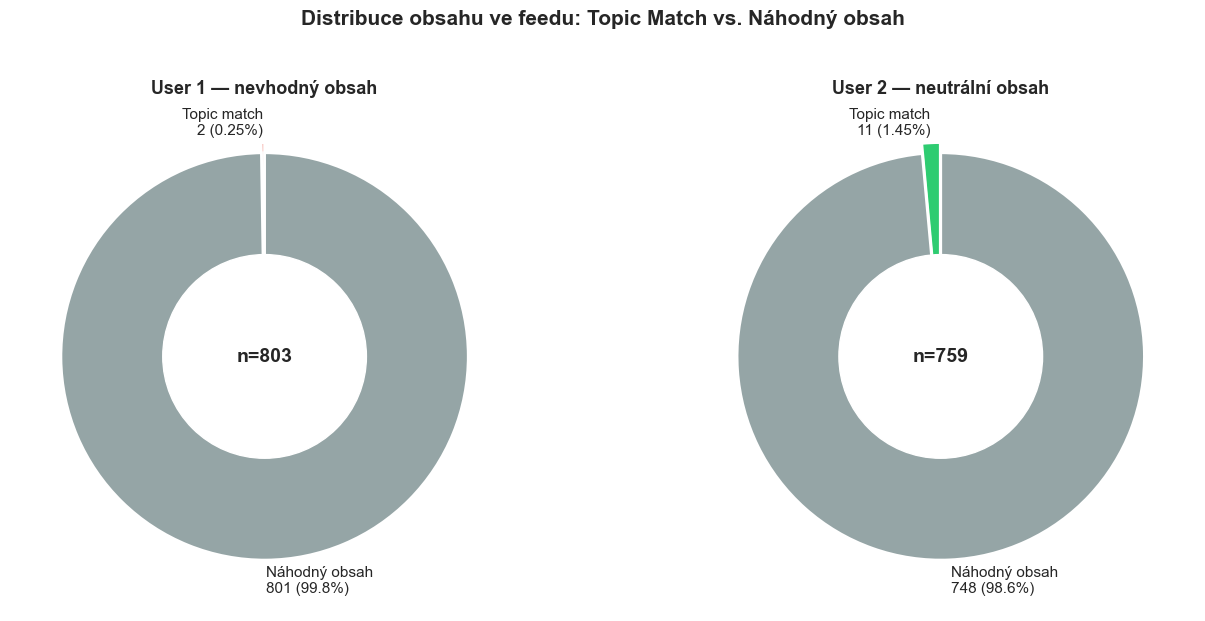


📊 User 1 (nevhodný obsah): pouze 2 z 803 videí (0.25%) odpovídá hledaným tématům
📊 User 2 (neutrální obsah): 11 z 759 videí (1.45%) odpovídá hledaným tématům


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, (df, label, color) in enumerate([
    (df1, 'User 1 — nevhodný obsah', COLORS['user1']),
    (df2, 'User 2 — neutrální obsah', COLORS['user2'])
]):
    ax = axes[idx]
    
    match_count = df['is_topic_match'].sum()
    random_count = (~df['is_topic_match']).sum()
    total = len(df)
    
    sizes = [match_count, random_count]
    labels_pie = [f'Topic match\n{match_count} ({match_count/total*100:.2f}%)',
                  f'Náhodný obsah\n{random_count} ({random_count/total*100:.1f}%)']
    colors_pie = [color, COLORS['random']]
    explode = (0.05, 0)
    
    wedges, texts, autotexts = ax.pie(
        sizes, labels=labels_pie, autopct='', colors=colors_pie,
        startangle=90, explode=explode,
        wedgeprops={'linewidth': 2, 'edgecolor': 'white'}
    )
    
    # Donut
    centre = plt.Circle((0, 0), 0.5, fc='white')
    ax.add_patch(centre)
    ax.text(0, 0, f'n={total}', ha='center', va='center', fontsize=14, fontweight='bold')
    
    ax.set_title(label, fontweight='bold', fontsize=13)

plt.suptitle('Distribuce obsahu ve feedu: Topic Match vs. Náhodný obsah',
             fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('output/02_global_distribution.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print(f"\n📊 User 1 (nevhodný obsah): pouze {df1['is_topic_match'].sum()} z {len(df1)} videí ({df1['is_topic_match'].mean()*100:.2f}%) odpovídá hledaným tématům")
print(f"📊 User 2 (neutrální obsah): {df2['is_topic_match'].sum()} z {len(df2)} videí ({df2['is_topic_match'].mean()*100:.2f}%) odpovídá hledaným tématům")

## 5.2 Detailní breakdown predicted topics

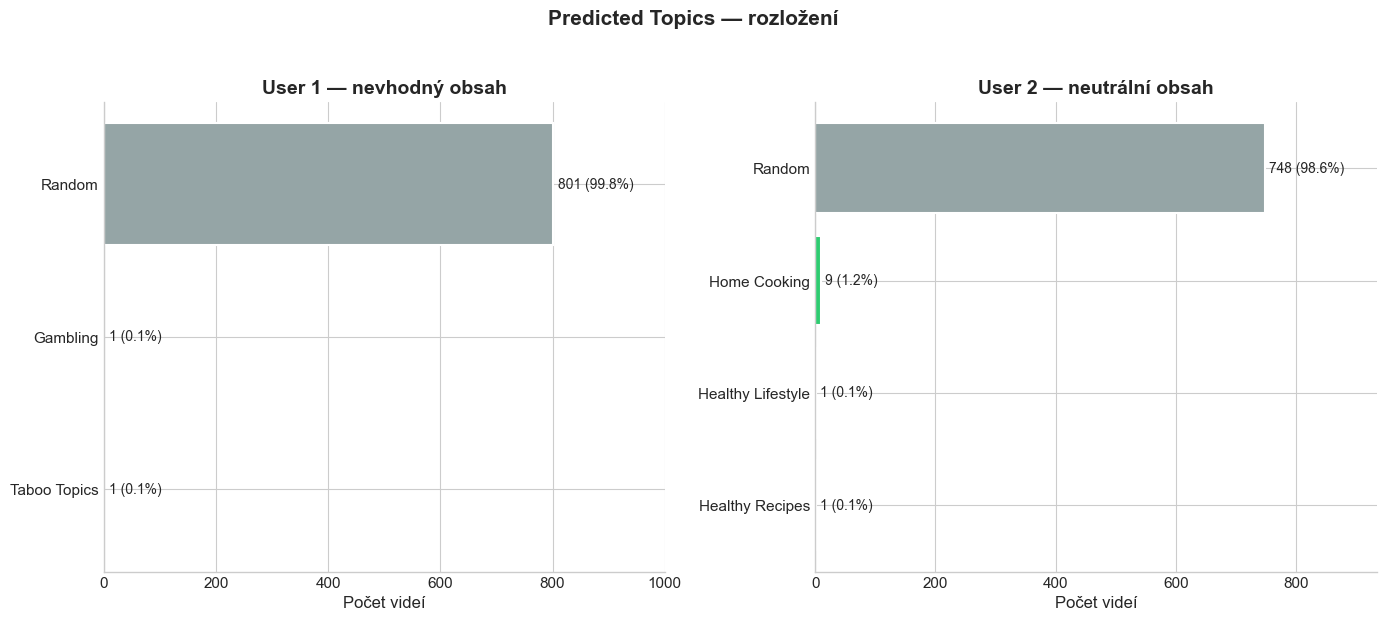

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, (df, label, color) in enumerate([
    (df1, 'User 1 — nevhodný obsah', COLORS['user1']),
    (df2, 'User 2 — neutrální obsah', COLORS['user2'])
]):
    ax = axes[idx]
    
    topic_counts = df['predicted_topic'].value_counts()
    
    colors_bar = [color if t != 'random' else COLORS['random'] for t in topic_counts.index]
    
    bars = ax.barh(range(len(topic_counts)), topic_counts.values, color=colors_bar,
                   edgecolor='white', linewidth=1.5)
    ax.set_yticks(range(len(topic_counts)))
    ax.set_yticklabels([t.replace('_', ' ').title() for t in topic_counts.index])
    ax.invert_yaxis()
    
    for bar, val in zip(bars, topic_counts.values):
        pct = val / len(df) * 100
        ax.text(val + len(df)*0.01, bar.get_y() + bar.get_height()/2,
                f'{val:,} ({pct:.1f}%)', va='center', fontsize=10)
    
    ax.set_xlabel('Počet videí')
    ax.set_title(label, fontweight='bold')
    ax.set_xlim(0, max(topic_counts.values) * 1.25)

plt.suptitle('Predicted Topics — rozložení', fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('output/03_predicted_topics_breakdown.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

---
# 6. ANALÝZA ALGORITMICKÉ „BUBLINY"
---

## 6.1 Vývoj personalizace v průběhu session (Sliding Window)

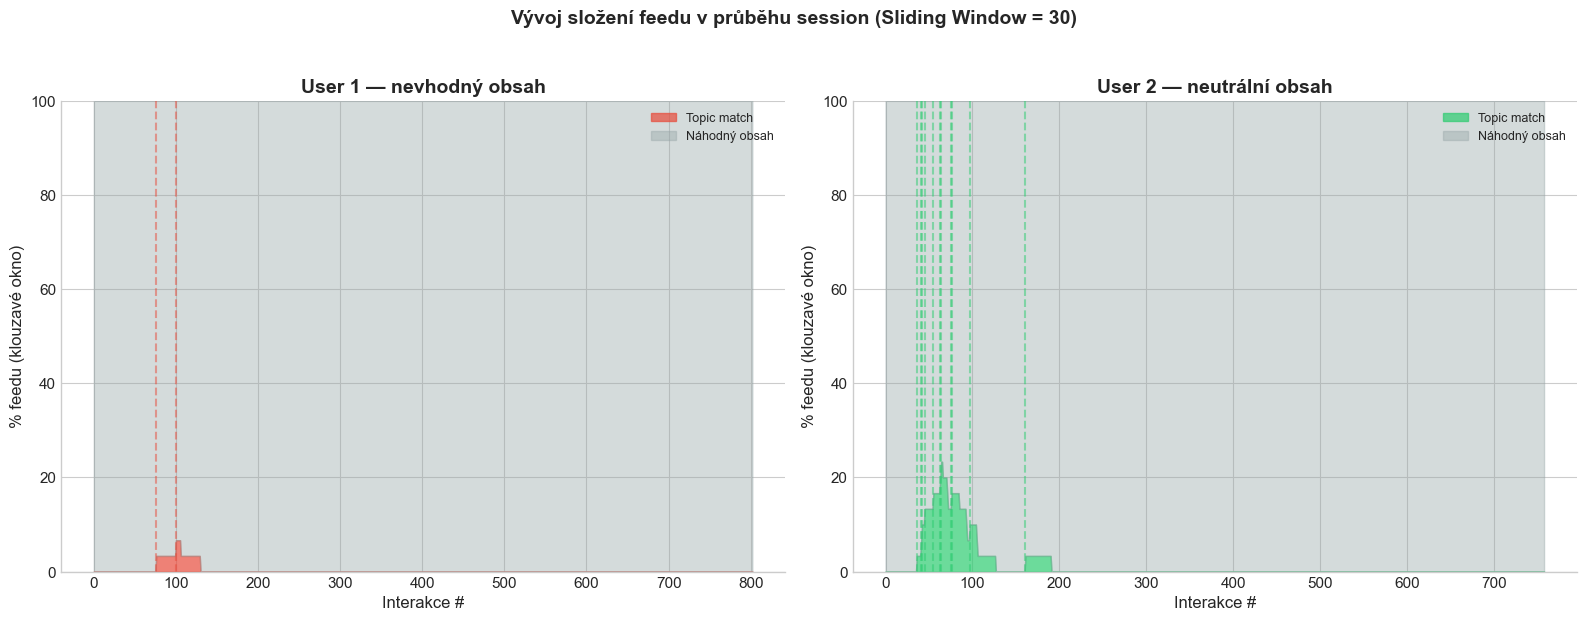


📈 Vertikální čárkované čáry označují momenty, kdy se ve feedu objevil topic match.


In [7]:
WINDOW = 30

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, (df, label, color) in enumerate([
    (df1, 'User 1 — nevhodný obsah', COLORS['user1']),
    (df2, 'User 2 — neutrální obsah', COLORS['user2'])
]):
    ax = axes[idx]
    
    sorted_df = df.sort_values('interaction_number').reset_index(drop=True)
    
    # Rolling match rate
    rolling_match = sorted_df['is_topic_match'].rolling(WINDOW, min_periods=1).mean() * 100
    rolling_random = 100 - rolling_match
    
    ax.fill_between(sorted_df.index, 0, rolling_match, alpha=0.7,
                    label='Topic match', color=color)
    ax.fill_between(sorted_df.index, rolling_match, 100, alpha=0.4,
                    label='Náhodný obsah', color=COLORS['random'])
    
    ax.set_xlabel('Interakce #')
    ax.set_ylabel('% feedu (klouzavé okno)')
    ax.set_title(label, fontweight='bold')
    ax.set_ylim(0, 100)
    ax.legend(loc='upper right', fontsize=9)
    
    # Označení topic match událostí
    match_indices = sorted_df[sorted_df['is_topic_match']].index
    for mi in match_indices:
        ax.axvline(x=mi, color=color, alpha=0.5, linewidth=1.5, linestyle='--')

plt.suptitle(f'Vývoj složení feedu v průběhu session (Sliding Window = {WINDOW})',
             fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('output/04_sliding_window.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print(f"\n📈 Vertikální čárkované čáry označují momenty, kdy se ve feedu objevil topic match.")

## 6.2 Kumulativní trend topic match

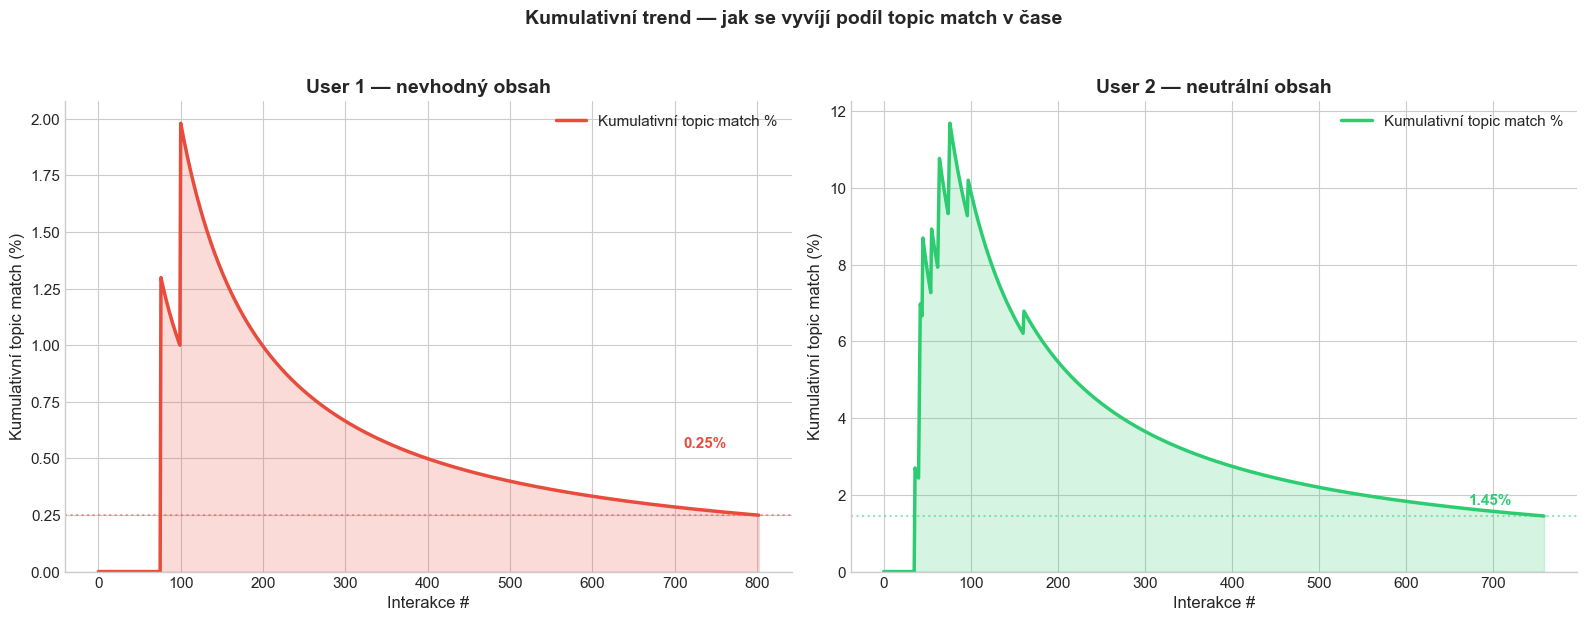

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, (df, label, color) in enumerate([
    (df1, 'User 1 — nevhodný obsah', COLORS['user1']),
    (df2, 'User 2 — neutrální obsah', COLORS['user2'])
]):
    ax = axes[idx]
    
    sorted_df = df.sort_values('interaction_number').reset_index(drop=True)
    cumulative_match = sorted_df['is_topic_match'].cumsum()
    cumulative_pct = cumulative_match / (sorted_df.index + 1) * 100
    
    ax.plot(sorted_df.index, cumulative_pct, color=color, linewidth=2.5, label='Kumulativní topic match %')
    ax.fill_between(sorted_df.index, 0, cumulative_pct, alpha=0.2, color=color)
    
    # Referenční linie
    final_pct = cumulative_pct.iloc[-1]
    ax.axhline(y=final_pct, color=color, linestyle=':', alpha=0.5)
    ax.text(len(sorted_df)*0.95, final_pct + 0.3, f'{final_pct:.2f}%',
            ha='right', fontweight='bold', color=color)
    
    ax.set_xlabel('Interakce #')
    ax.set_ylabel('Kumulativní topic match (%)')
    ax.set_title(label, fontweight='bold')
    ax.set_ylim(bottom=0)
    ax.legend(loc='upper right')

plt.suptitle('Kumulativní trend — jak se vyvíjí podíl topic match v čase',
             fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('output/05_cumulative_trend.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

---
# 7. ANALÝZA INTERAKCÍ
---

## 7.1 Engagement Funnel: Zobrazeno → Dokoukáno → Like → Bookmark

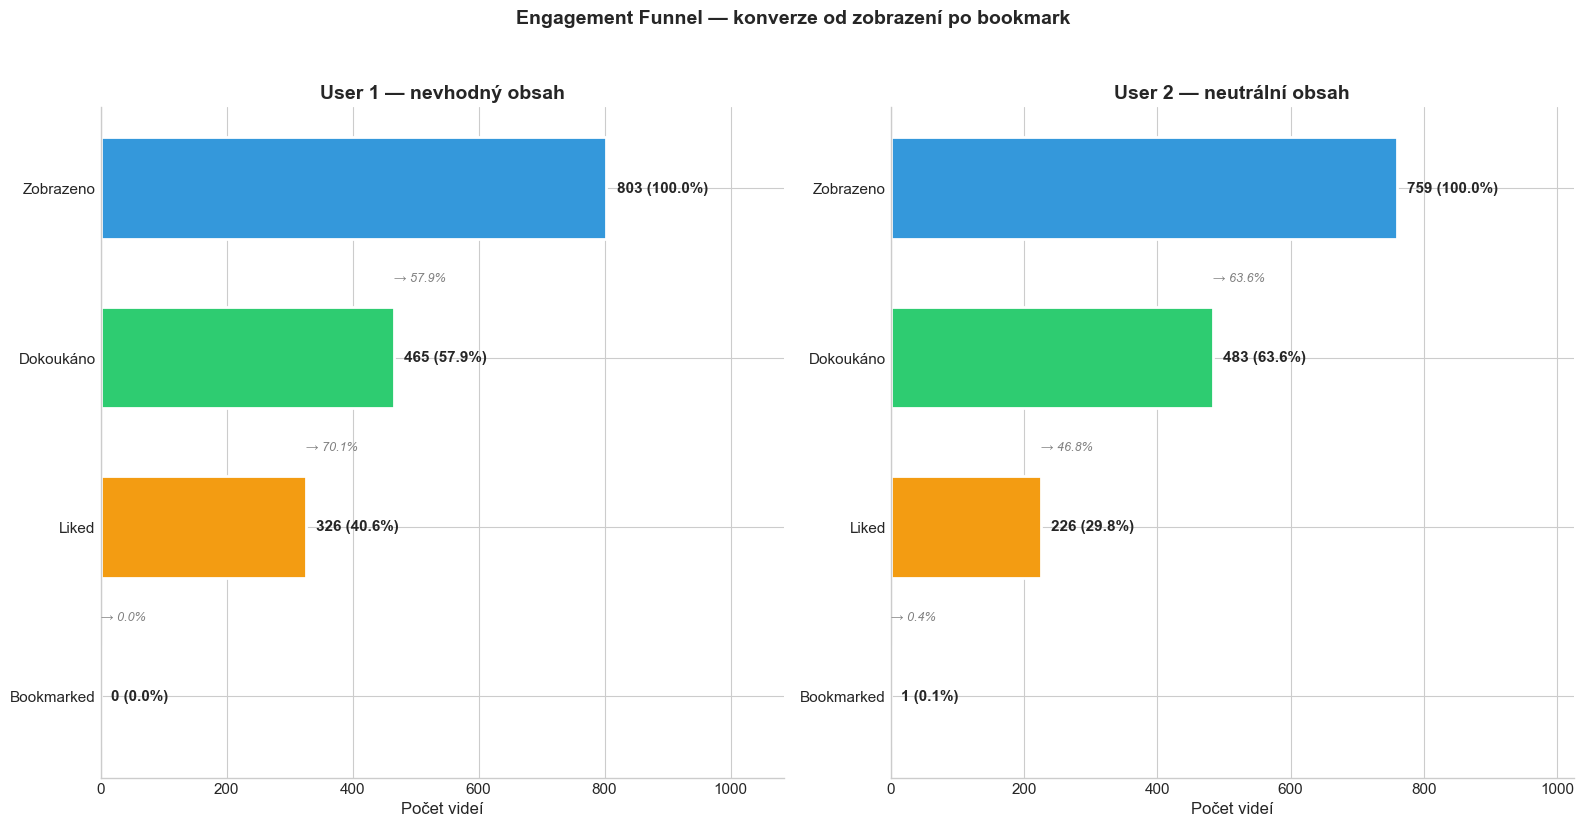

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for idx, (df, label, color) in enumerate([
    (df1, 'User 1 — nevhodný obsah', COLORS['user1']),
    (df2, 'User 2 — neutrální obsah', COLORS['user2'])
]):
    ax = axes[idx]
    
    total = len(df)
    watched = df['video_action_watch'].sum()
    liked = df['video_action_like'].sum()
    bookmarked = df['video_action_bookmark'].sum()
    
    stages = ['Zobrazeno', 'Dokoukáno', 'Liked', 'Bookmarked']
    values = [total, watched, liked, bookmarked]
    
    y_pos = range(len(stages)-1, -1, -1)
    
    bars = ax.barh(y_pos, values, color=COLORS['funnel'], edgecolor='white', linewidth=2, height=0.6)
    
    for i, (bar, stage, val) in enumerate(zip(bars, stages, values)):
        pct = val / total * 100
        ax.text(val + total*0.02, bar.get_y() + bar.get_height()/2,
                f'{val:,} ({pct:.1f}%)', va='center', fontsize=11, fontweight='bold')
    
    # Konverzní šipky
    for i in range(len(values)-1):
        if values[i] > 0:
            conv = values[i+1] / values[i] * 100
            ax.annotate(f'→ {conv:.1f}%',
                       xy=(values[i+1], y_pos[i+1] + 0.45),
                       fontsize=9, color='gray', style='italic')
    
    ax.set_yticks(y_pos)
    ax.set_yticklabels(stages)
    ax.set_xlabel('Počet videí')
    ax.set_title(label, fontweight='bold')
    ax.set_xlim(0, total * 1.35)

plt.suptitle('Engagement Funnel — konverze od zobrazení po bookmark',
             fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('output/06_engagement_funnel.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## 7.2 Heatmapa: Typ interakce × Topic Match / Random

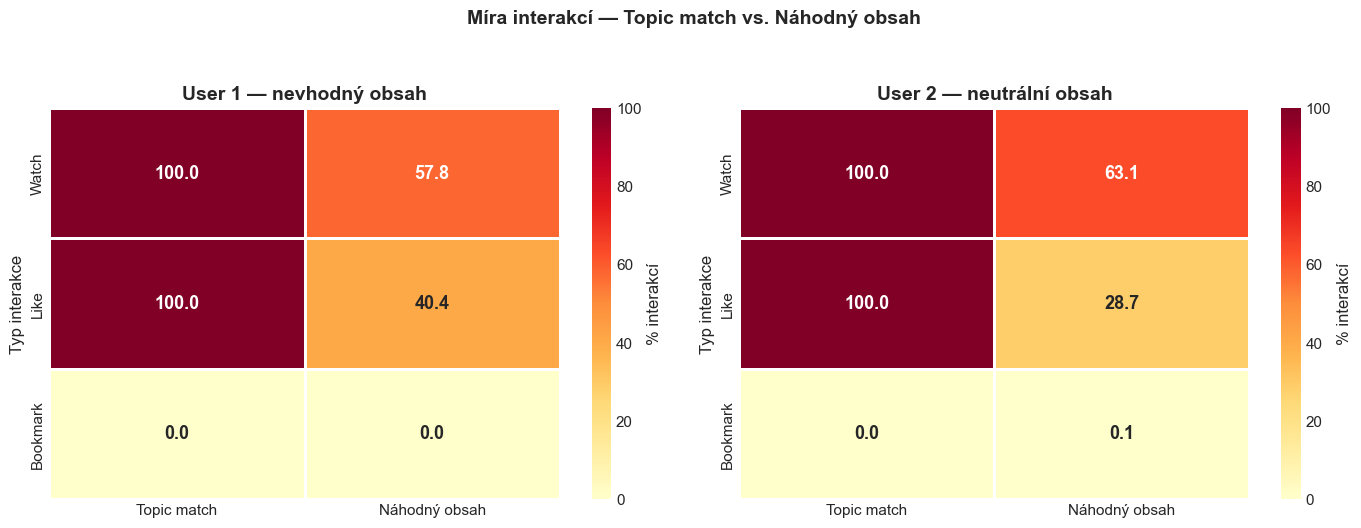

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, (df, label) in enumerate([
    (df1, 'User 1 — nevhodný obsah'),
    (df2, 'User 2 — neutrální obsah')
]):
    ax = axes[idx]
    
    categories_hm = ['Topic match', 'Náhodný obsah']
    actions = ['video_action_watch', 'video_action_like', 'video_action_bookmark']
    action_labels = ['Watch', 'Like', 'Bookmark']
    
    heatmap_data = []
    for action in actions:
        row = []
        for is_match in [True, False]:
            subset = df[df['is_topic_match'] == is_match]
            rate = subset[action].mean() * 100 if len(subset) > 0 else 0
            row.append(rate)
        heatmap_data.append(row)
    
    heatmap_df = pd.DataFrame(heatmap_data, index=action_labels, columns=categories_hm)
    
    sns.heatmap(heatmap_df, annot=True, fmt='.1f', cmap='YlOrRd',
                linewidths=2, linecolor='white', ax=ax,
                cbar_kws={'label': '% interakcí'},
                annot_kws={'size': 13, 'weight': 'bold'})
    ax.set_title(label, fontweight='bold')
    ax.set_ylabel('Typ interakce')

plt.suptitle('Míra interakcí — Topic match vs. Náhodný obsah',
             fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig('output/07_interaction_heatmap.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## 7.3 Srovnání Watch & Like rate mezi uživateli

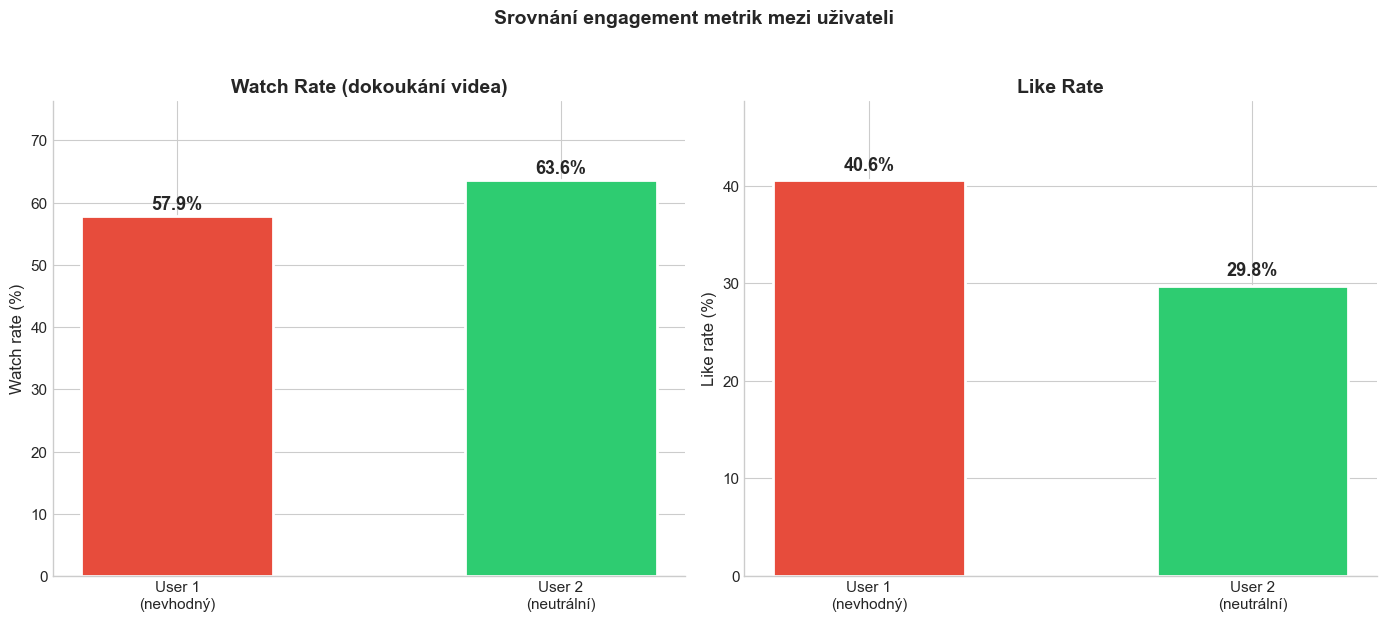

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Watch rate ---
ax = axes[0]
metrics_watch = {
    'User 1\n(nevhodný)': df1['video_action_watch'].mean() * 100,
    'User 2\n(neutrální)': df2['video_action_watch'].mean() * 100
}
bars = ax.bar(metrics_watch.keys(), metrics_watch.values(),
              color=[COLORS['user1'], COLORS['user2']], edgecolor='white', linewidth=2, width=0.5)
for bar, val in zip(bars, metrics_watch.values()):
    ax.text(bar.get_x() + bar.get_width()/2, val + 1, f'{val:.1f}%',
            ha='center', fontweight='bold', fontsize=13)
ax.set_ylabel('Watch rate (%)')
ax.set_title('Watch Rate (dokoukání videa)', fontweight='bold')
ax.set_ylim(0, max(metrics_watch.values()) * 1.2)

# --- Like rate ---
ax = axes[1]
metrics_like = {
    'User 1\n(nevhodný)': df1['video_action_like'].mean() * 100,
    'User 2\n(neutrální)': df2['video_action_like'].mean() * 100
}
bars = ax.bar(metrics_like.keys(), metrics_like.values(),
              color=[COLORS['user1'], COLORS['user2']], edgecolor='white', linewidth=2, width=0.5)
for bar, val in zip(bars, metrics_like.values()):
    ax.text(bar.get_x() + bar.get_width()/2, val + 1, f'{val:.1f}%',
            ha='center', fontweight='bold', fontsize=13)
ax.set_ylabel('Like rate (%)')
ax.set_title('Like Rate', fontweight='bold')
ax.set_ylim(0, max(metrics_like.values()) * 1.2)

plt.suptitle('Srovnání engagement metrik mezi uživateli',
             fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('output/08_watch_like_comparison.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

---
# 8. ANALÝZA DÉLKY VIDEÍ
---

## 8.1 Distribuce délky videí

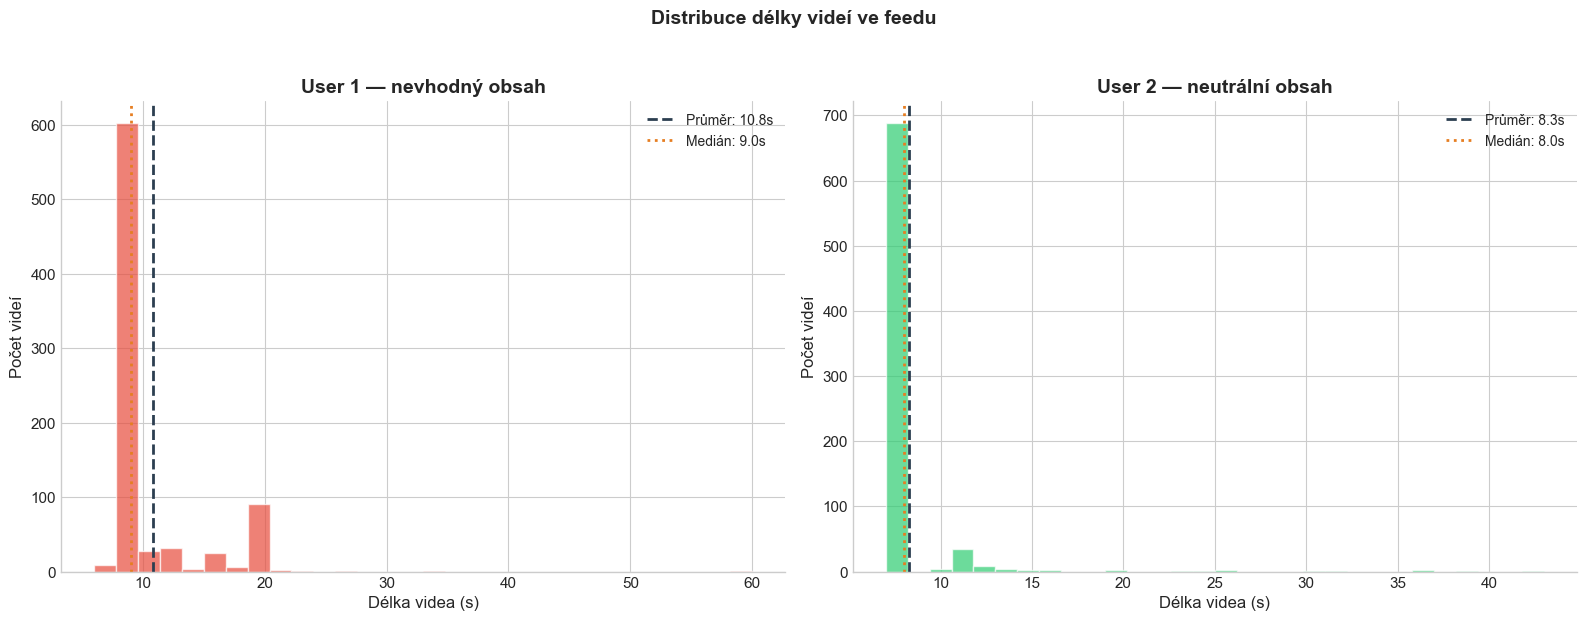

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, (df, label, color) in enumerate([
    (df1, 'User 1 — nevhodný obsah', COLORS['user1']),
    (df2, 'User 2 — neutrální obsah', COLORS['user2'])
]):
    ax = axes[idx]
    
    # Histogram
    ax.hist(df['video_time_duration'], bins=30, color=color, alpha=0.7,
            edgecolor='white', linewidth=1)
    
    # Průměr a medián
    mean_dur = df['video_time_duration'].mean()
    median_dur = df['video_time_duration'].median()
    
    ax.axvline(mean_dur, color='#2c3e50', linestyle='--', linewidth=2, label=f'Průměr: {mean_dur:.1f}s')
    ax.axvline(median_dur, color='#e67e22', linestyle=':', linewidth=2, label=f'Medián: {median_dur:.1f}s')
    
    ax.set_xlabel('Délka videa (s)')
    ax.set_ylabel('Počet videí')
    ax.set_title(label, fontweight='bold')
    ax.legend(fontsize=10)

plt.suptitle('Distribuce délky videí ve feedu', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('output/09_video_duration.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## 8.2 Délka videa vs. interakce

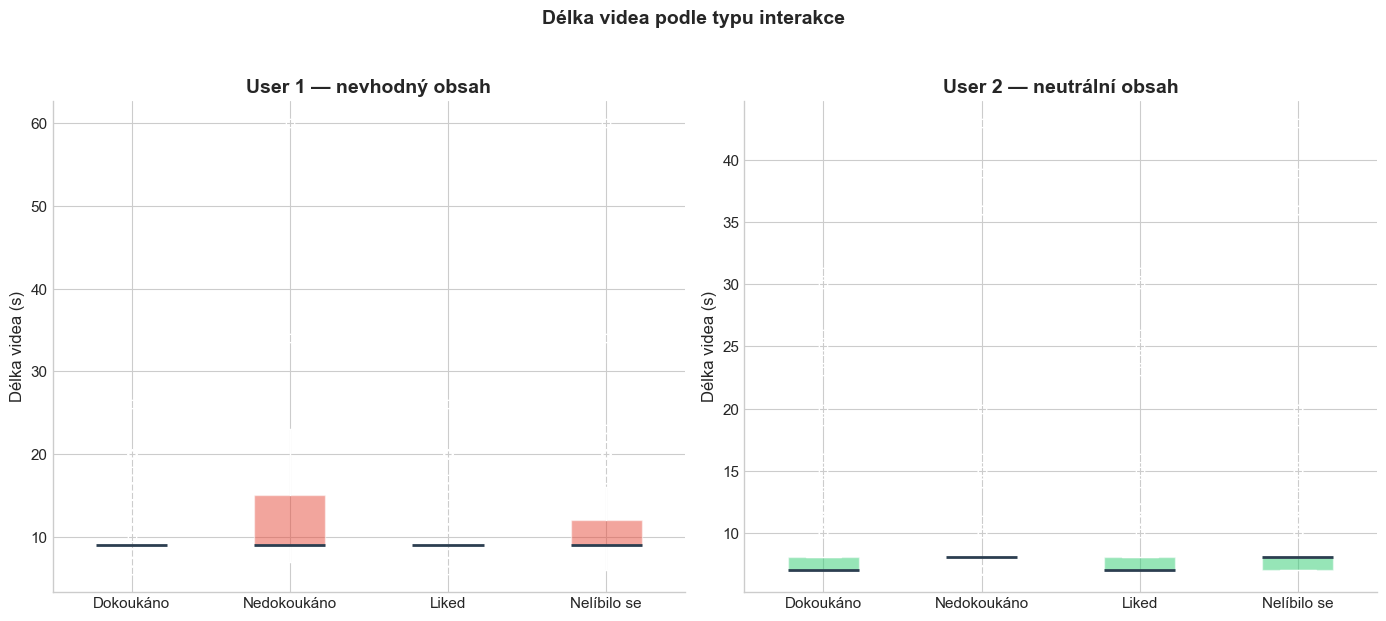

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, (df, label, color) in enumerate([
    (df1, 'User 1 — nevhodný obsah', COLORS['user1']),
    (df2, 'User 2 — neutrální obsah', COLORS['user2'])
]):
    ax = axes[idx]
    
    # Boxplot délky podle akce
    data_groups = {
        'Dokoukáno': df[df['video_action_watch'] == True]['video_time_duration'],
        'Nedokoukáno': df[df['video_action_watch'] == False]['video_time_duration'],
        'Liked': df[df['video_action_like'] == True]['video_time_duration'],
        'Nelíbilo se': df[df['video_action_like'] == False]['video_time_duration']
    }
    
    bp = ax.boxplot(data_groups.values(), labels=data_groups.keys(), patch_artist=True,
                    boxprops=dict(facecolor=color, alpha=0.5),
                    medianprops=dict(color='#2c3e50', linewidth=2))
    
    ax.set_ylabel('Délka videa (s)')
    ax.set_title(label, fontweight='bold')

plt.suptitle('Délka videa podle typu interakce', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('output/10_duration_vs_actions.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

---
# 9. TOPIC MATCH — DETAILNÍ ANALÝZA
---

Tato sekce zkoumá vzácné případy, kdy algoritmus skutečně doporučil obsah odpovídající hledaným tématům uživatele.

In [14]:
# === Detailní pohled na topic match videa ===
print("=" * 80)
print("USER 1 — NEVHODNÝ OBSAH: Videa s topic match")
print("=" * 80)

match1 = df1[df1['is_topic_match']].copy()
if len(match1) > 0:
    for _, row in match1.iterrows():
        print(f"\n  📍 Interakce #{row['interaction_number']}")
        print(f"     Predicted topic: {row['predicted_topic']}")
        print(f"     Autor: {row['video_author']}")
        print(f"     Popis: {row['video_description'][:120]}...")
        print(f"     Dokoukáno: {'✓' if row['video_action_watch'] else '✗'} | Like: {'✓' if row['video_action_like'] else '✗'}")
        print(f"     Délka: {row['video_time_duration']}s")
else:
    print("  Žádné topic match videa!")

print("\n" + "=" * 80)
print("USER 2 — NEUTRÁLNÍ OBSAH: Videa s topic match")
print("=" * 80)

match2 = df2[df2['is_topic_match']].copy()
if len(match2) > 0:
    for _, row in match2.iterrows():
        print(f"\n  📍 Interakce #{row['interaction_number']}")
        print(f"     Predicted topic: {row['predicted_topic']}")
        print(f"     Autor: {row['video_author']}")
        print(f"     Popis: {row['video_description'][:120]}...")
        print(f"     Dokoukáno: {'✓' if row['video_action_watch'] else '✗'} | Like: {'✓' if row['video_action_like'] else '✗'}")
        print(f"     Délka: {row['video_time_duration']}s")
else:
    print("  Žádné topic match videa!")

print(f"\n{'=' * 80}")
print(f"SOUHRN:")
print(f"  User 1: {len(match1)} topic match z {len(df1)} videí ({len(match1)/len(df1)*100:.2f}%)")
print(f"  User 2: {len(match2)} topic match z {len(df2)} videí ({len(match2)/len(df2)*100:.2f}%)")

USER 1 — NEVHODNÝ OBSAH: Videa s topic match

  📍 Interakce #77
     Predicted topic: gambling
     Autor: erigor04
     Popis: Reel by erigor04. Double-tap to play or pause....
     Dokoukáno: ✓ | Like: ✓
     Délka: 8s

  📍 Interakce #101
     Predicted topic: taboo_topics
     Autor: perceptiveyed
     Popis: Reel by perceptiveyed. Double-tap to play or pause....
     Dokoukáno: ✓ | Like: ✓
     Délka: 13s

USER 2 — NEUTRÁLNÍ OBSAH: Videa s topic match

  📍 Interakce #37
     Predicted topic: home_cooking
     Autor: terapiezivota
     Popis: Profilový obrázek terapiezivota #syr #recept #rychlyrecept...
     Dokoukáno: ✓ | Like: ✓
     Délka: 12s

  📍 Interakce #42
     Predicted topic: home_cooking
     Autor: sakuras_sushi
     Popis: Profilový obrázek sakuras_sushi #sakurassushi #kamnasushi #sushirestaurace #kamvpraze #sushipraha...
     Dokoukáno: ✓ | Like: ✓
     Délka: 24s

  📍 Interakce #43
     Predicted topic: home_cooking
     Autor: nejen_detem
     Popis: John Williams ·

## 9.2 Kdy v session se topic match objevil?

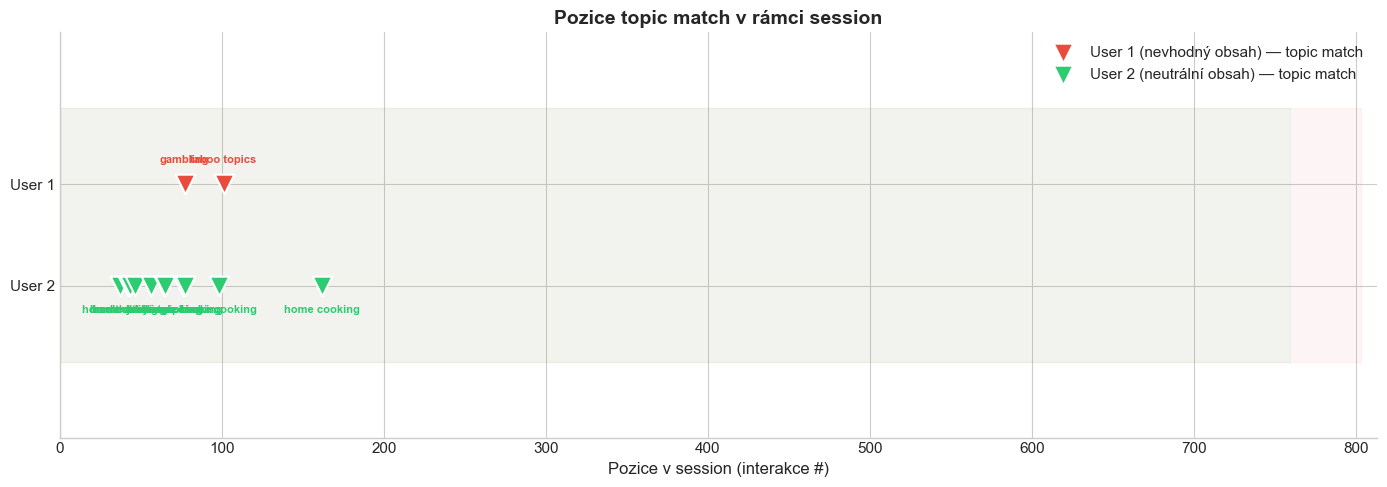

In [15]:
fig, ax = plt.subplots(figsize=(14, 5))

# Pozice topic match v rámci session
for df, label, color, offset in [
    (df1, 'User 1 (nevhodný obsah)', COLORS['user1'], 0.2),
    (df2, 'User 2 (neutrální obsah)', COLORS['user2'], -0.2)
]:
    matches = df[df['is_topic_match']]
    if len(matches) > 0:
        positions = matches['interaction_number'].values
        ax.scatter(positions, [offset]*len(positions), s=200, color=color,
                  marker='v', zorder=5, label=f'{label} — topic match', edgecolors='white', linewidth=1.5)
        for pos in positions:
            topic = matches[matches['interaction_number'] == pos]['predicted_topic'].iloc[0]
            ax.annotate(topic.replace('_', ' '), (pos, offset),
                       textcoords="offset points", xytext=(0, 15 if offset > 0 else -20),
                       ha='center', fontsize=8, fontweight='bold', color=color)

# Session range
max_len = max(len(df1), len(df2))
ax.fill_between([0, len(df1)], -0.5, 0.5, alpha=0.05, color=COLORS['user1'])
ax.fill_between([0, len(df2)], -0.5, 0.5, alpha=0.05, color=COLORS['user2'])

ax.set_xlabel('Pozice v session (interakce #)')
ax.set_ylabel('')
ax.set_yticks([0.2, -0.2])
ax.set_yticklabels(['User 1', 'User 2'])
ax.set_ylim(-0.8, 0.8)
ax.set_xlim(0, max_len + 10)
ax.set_title('Pozice topic match v rámci session', fontweight='bold')
ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig('output/11_topic_match_positions.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

---
# 10. SROVNÁNÍ PROFILŮ — RADAR CHART
---

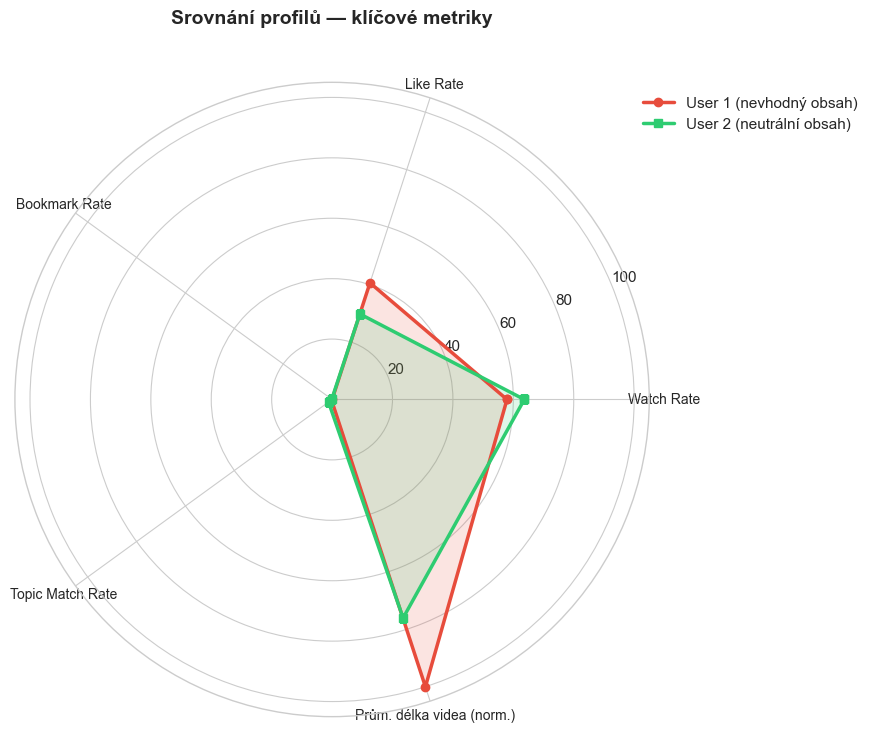


Hodnoty pro radar chart:
  Watch Rate                    : User1=57.91%  User2=63.64%
  Like Rate                     : User1=40.60%  User2=29.78%
  Bookmark Rate                 : User1=0.00%  User2=0.13%
  Topic Match Rate              : User1=0.25%  User2=1.45%
  Prům. délka videa (norm.)     : User1=100.00%  User2=76.07%


In [16]:
# === Radar chart: srovnání obou uživatelů ===
categories_radar = ['Watch Rate', 'Like Rate', 'Bookmark Rate',
                    'Topic Match Rate', 'Prům. délka videa (norm.)']
N = len(categories_radar)

# Metriky
def get_radar_metrics(df):
    max_dur = max(df1['video_time_duration'].mean(), df2['video_time_duration'].mean())
    return [
        df['video_action_watch'].mean() * 100,
        df['video_action_like'].mean() * 100,
        df['video_action_bookmark'].mean() * 100,
        df['is_topic_match'].mean() * 100,
        df['video_time_duration'].mean() / max_dur * 100  # normalizace
    ]

vals1 = get_radar_metrics(df1)
vals2 = get_radar_metrics(df2)

angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]
vals1 += vals1[:1]
vals2 += vals2[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

ax.plot(angles, vals1, 'o-', linewidth=2.5, label='User 1 (nevhodný obsah)', color=COLORS['user1'])
ax.fill(angles, vals1, alpha=0.15, color=COLORS['user1'])
ax.plot(angles, vals2, 's-', linewidth=2.5, label='User 2 (neutrální obsah)', color=COLORS['user2'])
ax.fill(angles, vals2, alpha=0.15, color=COLORS['user2'])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories_radar, size=10)
ax.set_title('Srovnání profilů — klíčové metriky', fontweight='bold', size=14, y=1.08)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.0))

plt.tight_layout()
plt.savefig('output/12_radar_comparison.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# Print radar values
print("\nHodnoty pro radar chart:")
for cat, v1, v2 in zip(categories_radar, vals1[:-1], vals2[:-1]):
    print(f"  {cat:30s}: User1={v1:.2f}%  User2={v2:.2f}%")

---
# 11. ENGAGEMENT V PRŮBĚHU SESSION
---

## 11.1 Watch rate v průběhu session (klouzavý průměr)

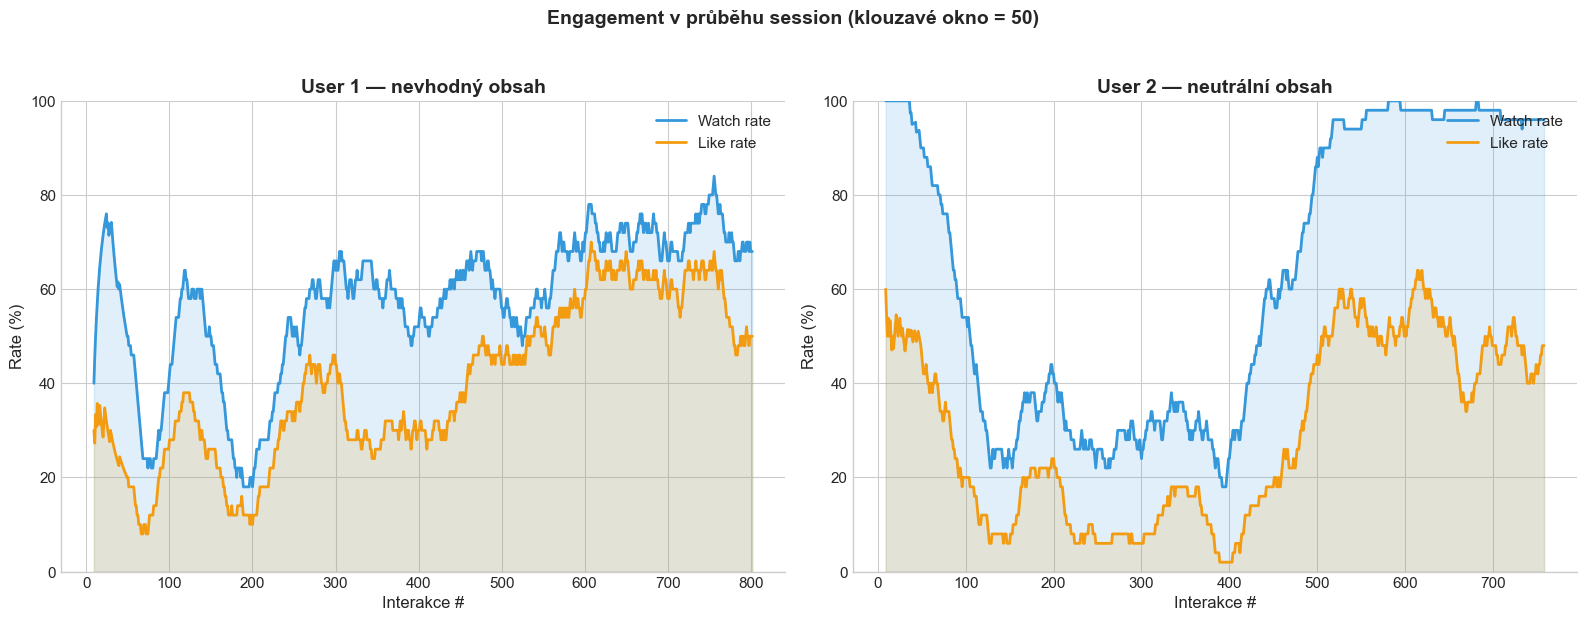

In [17]:
WINDOW = 50

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, (df, label, color) in enumerate([
    (df1, 'User 1 — nevhodný obsah', COLORS['user1']),
    (df2, 'User 2 — neutrální obsah', COLORS['user2'])
]):
    ax = axes[idx]
    
    sorted_df = df.sort_values('interaction_number').reset_index(drop=True)
    
    rolling_watch = sorted_df['video_action_watch'].rolling(WINDOW, min_periods=10).mean() * 100
    rolling_like = sorted_df['video_action_like'].rolling(WINDOW, min_periods=10).mean() * 100
    
    ax.plot(sorted_df.index, rolling_watch, color=COLORS['watch'], linewidth=2, label='Watch rate')
    ax.plot(sorted_df.index, rolling_like, color=COLORS['like'], linewidth=2, label='Like rate')
    
    ax.fill_between(sorted_df.index, rolling_watch, alpha=0.15, color=COLORS['watch'])
    ax.fill_between(sorted_df.index, rolling_like, alpha=0.15, color=COLORS['like'])
    
    ax.set_xlabel('Interakce #')
    ax.set_ylabel('Rate (%)')
    ax.set_title(label, fontweight='bold')
    ax.legend(loc='upper right')
    ax.set_ylim(0, 100)

plt.suptitle(f'Engagement v průběhu session (klouzavé okno = {WINDOW})',
             fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('output/13_engagement_over_time.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## 11.2 Vzor interakcí v průběhu session — stacked area

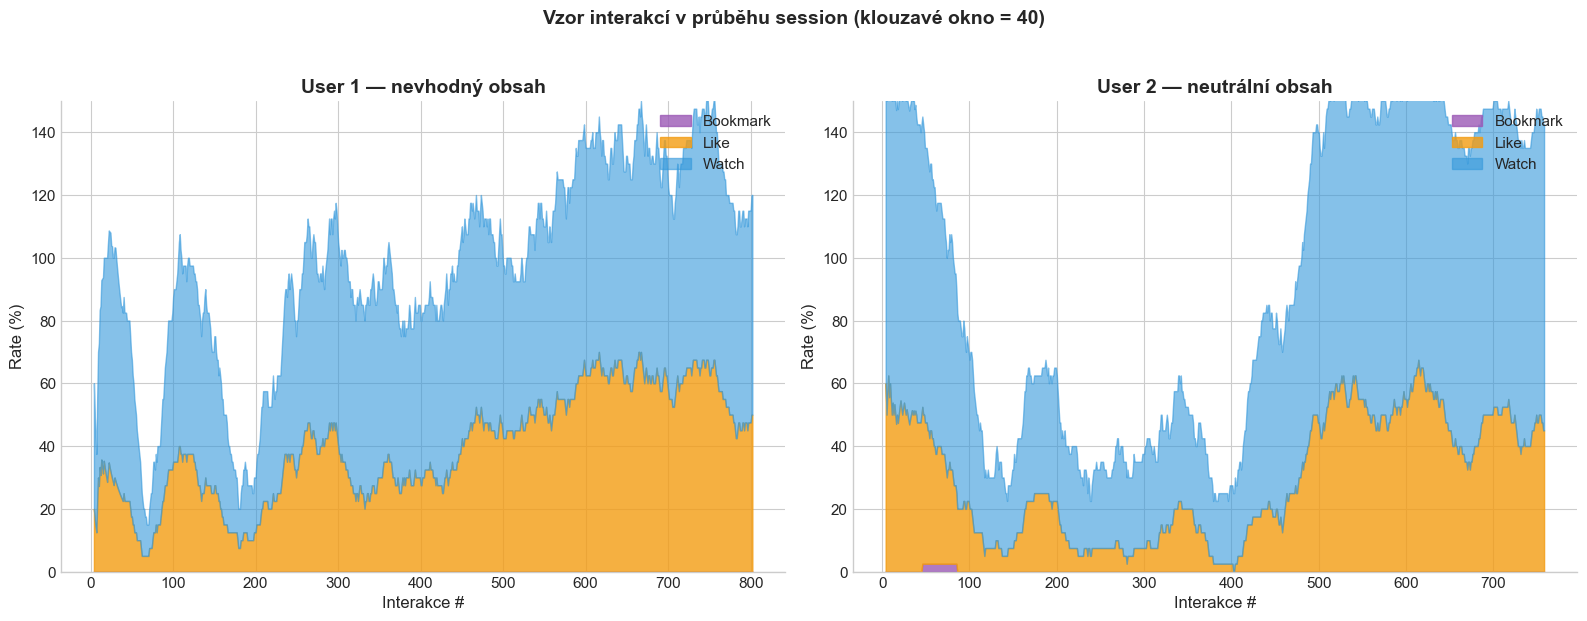

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

WINDOW_AREA = 40

for idx, (df, label, color) in enumerate([
    (df1, 'User 1 — nevhodný obsah', COLORS['user1']),
    (df2, 'User 2 — neutrální obsah', COLORS['user2'])
]):
    ax = axes[idx]
    
    sorted_df = df.sort_values('interaction_number').reset_index(drop=True)
    
    r_watch = sorted_df['video_action_watch'].rolling(WINDOW_AREA, min_periods=5).mean() * 100
    r_like = sorted_df['video_action_like'].rolling(WINDOW_AREA, min_periods=5).mean() * 100
    r_bookmark = sorted_df['video_action_bookmark'].rolling(WINDOW_AREA, min_periods=5).mean() * 100
    
    ax.fill_between(sorted_df.index, 0, r_bookmark, alpha=0.8, color=COLORS['bookmark'], label='Bookmark')
    ax.fill_between(sorted_df.index, r_bookmark, r_bookmark + r_like, alpha=0.8, color=COLORS['like'], label='Like')
    ax.fill_between(sorted_df.index, r_bookmark + r_like, r_bookmark + r_like + r_watch,
                    alpha=0.6, color=COLORS['watch'], label='Watch')
    
    ax.set_xlabel('Interakce #')
    ax.set_ylabel('Rate (%)')
    ax.set_title(label, fontweight='bold')
    ax.legend(loc='upper right')
    ax.set_ylim(0, 150)

plt.suptitle(f'Vzor interakcí v průběhu session (klouzavé okno = {WINDOW_AREA})',
             fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('output/14_interaction_pattern.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

---
# 12. ANALÝZA AUTORŮ OBSAHU
---

## 12.1 Top autoři ve feedu

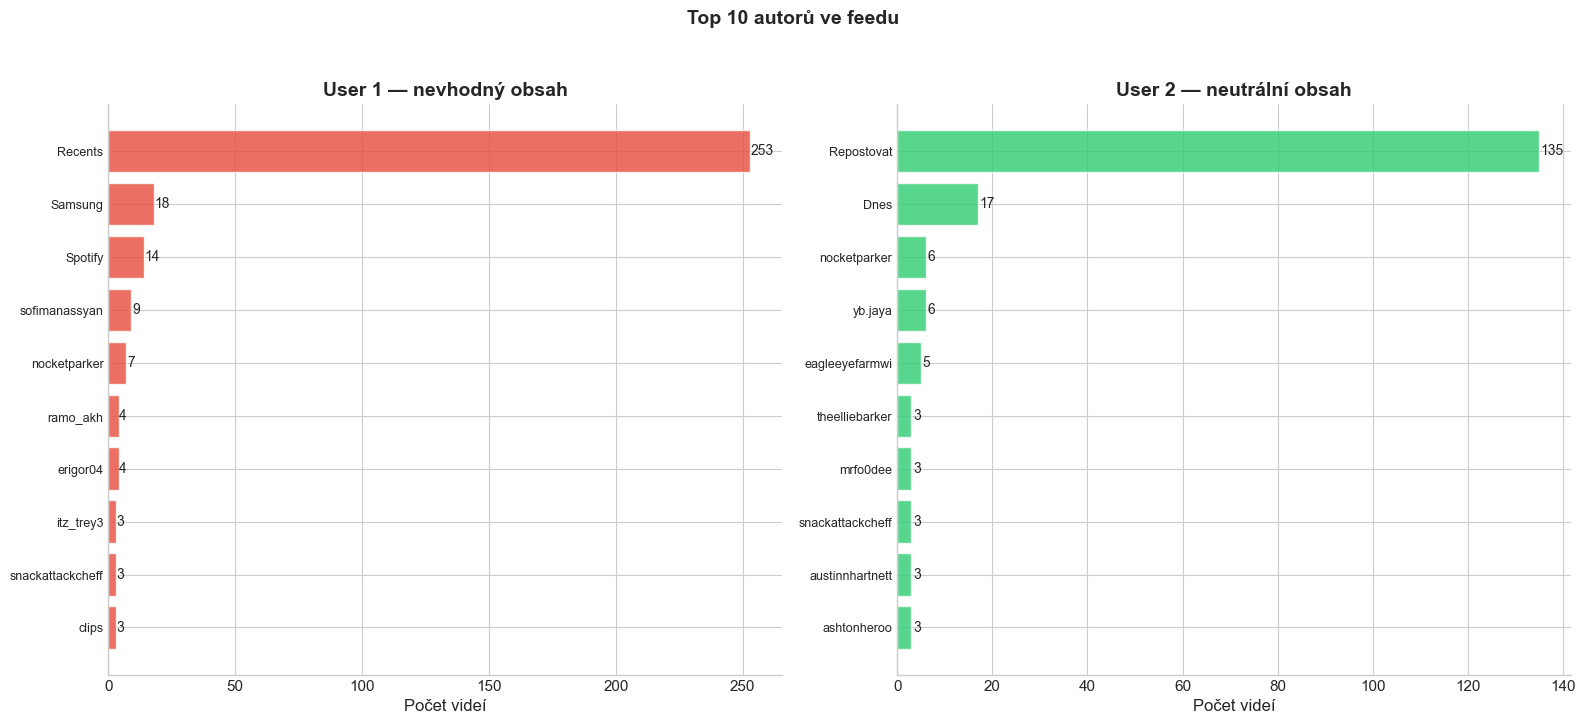


📊 User 1: 460 unikátních autorů z 803 videí
📊 User 2: 511 unikátních autorů z 759 videí


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for idx, (df, label, color) in enumerate([
    (df1, 'User 1 — nevhodný obsah', COLORS['user1']),
    (df2, 'User 2 — neutrální obsah', COLORS['user2'])
]):
    ax = axes[idx]
    
    top_authors = df['video_author'].value_counts().head(10)
    
    bars = ax.barh(range(len(top_authors)), top_authors.values, color=color,
                   alpha=0.8, edgecolor='white', linewidth=1)
    ax.set_yticks(range(len(top_authors)))
    ax.set_yticklabels([a[:25] + '…' if len(str(a)) > 25 else str(a) for a in top_authors.index],
                       fontsize=9)
    ax.invert_yaxis()
    
    for bar, val in zip(bars, top_authors.values):
        ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
                f'{val}', va='center', fontsize=10)
    
    ax.set_xlabel('Počet videí')
    ax.set_title(label, fontweight='bold')

plt.suptitle('Top 10 autorů ve feedu', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('output/15_top_authors.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# Unikátní autoři
print(f"\n📊 User 1: {df1['video_author'].nunique()} unikátních autorů z {len(df1)} videí")
print(f"📊 User 2: {df2['video_author'].nunique()} unikátních autorů z {len(df2)} videí")

---
# 13. ANALÝZA POPISKŮ VIDEÍ
---

## 13.1 Nejčastější slova v popisech videí

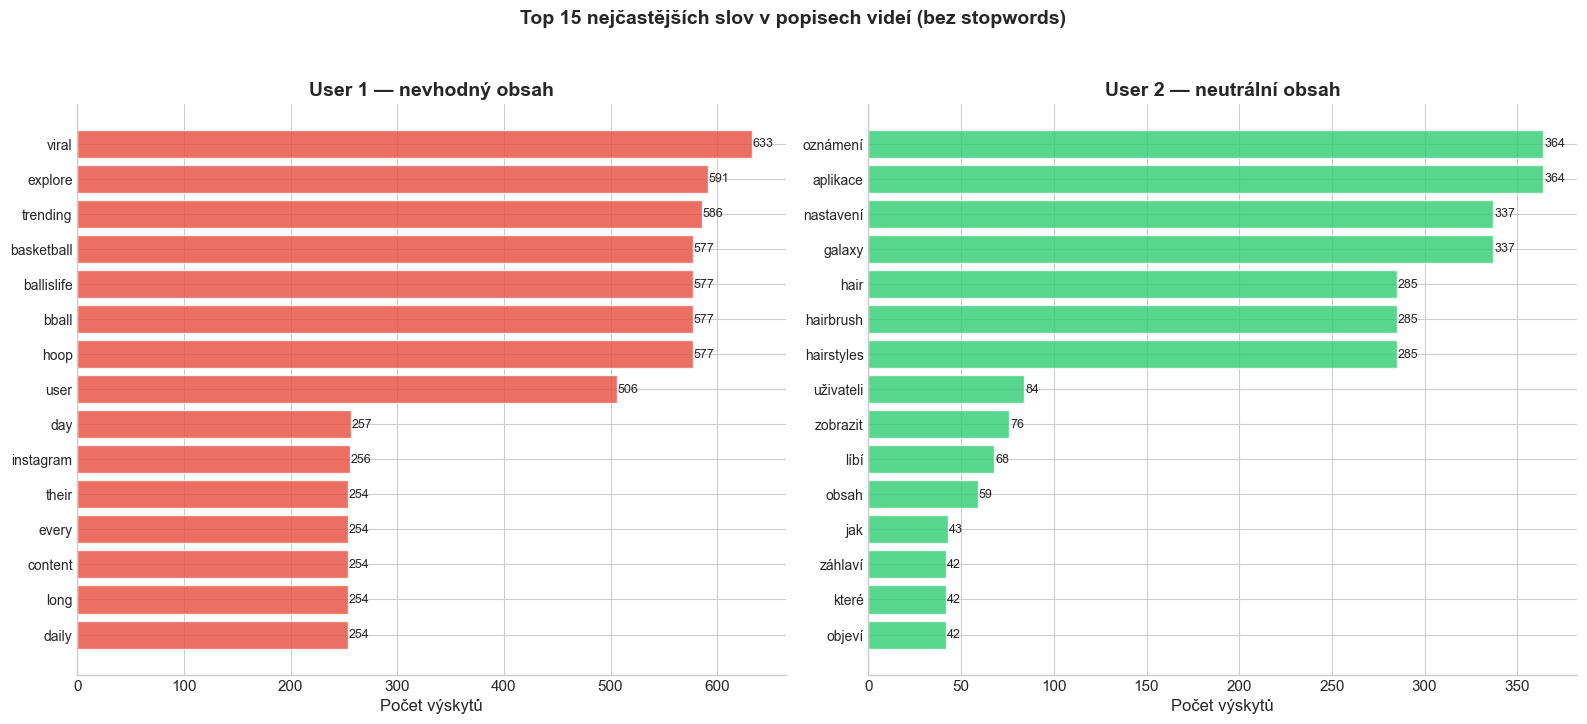

In [20]:
import re
from collections import Counter

# Stopwords (české + anglické + Instagram specifické)
STOPWORDS = {'a', 'je', 'na', 'se', 'to', 'v', 'the', 'and', 'is', 'in', 'of', 'for', 'to',
             'reel', 'by', 'reels', 'profilový', 'obrázek', 'double-tap', 'play', 'pause',
             'or', 'with', 'this', 'that', 'from', 'you', 'your', 'we', 'our', 'my', 'me',
             'it', 'its', 'was', 'are', 'be', 'do', 'an', 'at', 'as', 'but', 'not', 'so',
             'he', 'she', 'they', 'them', 'his', 'her', 'has', 'had', 'have', 'been', 'if',
             'no', 'up', 'out', 'all', 'can', 'get', 'got', 'just', 'when', 'one', 'what',
             'i', 'who', 'will', 'how', 'about', 'like', 'which', 'more', 'than', 'also'}

def extract_words(descriptions, min_len=3):
    words = []
    for desc in descriptions.dropna():
        tokens = re.findall(r'[a-záčďéěíňóřšťúůýž]+', str(desc).lower())
        words.extend([w for w in tokens if len(w) >= min_len and w not in STOPWORDS])
    return Counter(words)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for idx, (df, label, color) in enumerate([
    (df1, 'User 1 — nevhodný obsah', COLORS['user1']),
    (df2, 'User 2 — neutrální obsah', COLORS['user2'])
]):
    ax = axes[idx]
    
    word_counts = extract_words(df['video_description']).most_common(15)
    words, counts = zip(*word_counts)
    
    bars = ax.barh(range(len(words)), counts, color=color, alpha=0.8, edgecolor='white')
    ax.set_yticks(range(len(words)))
    ax.set_yticklabels(words, fontsize=10)
    ax.invert_yaxis()
    
    for bar, val in zip(bars, counts):
        ax.text(val + 0.5, bar.get_y() + bar.get_height()/2, str(val),
                va='center', fontsize=9)
    
    ax.set_xlabel('Počet výskytů')
    ax.set_title(label, fontweight='bold')

plt.suptitle('Top 15 nejčastějších slov v popisech videí (bez stopwords)',
             fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('output/16_word_frequency.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## 13.2 Nejčastější hashtagy

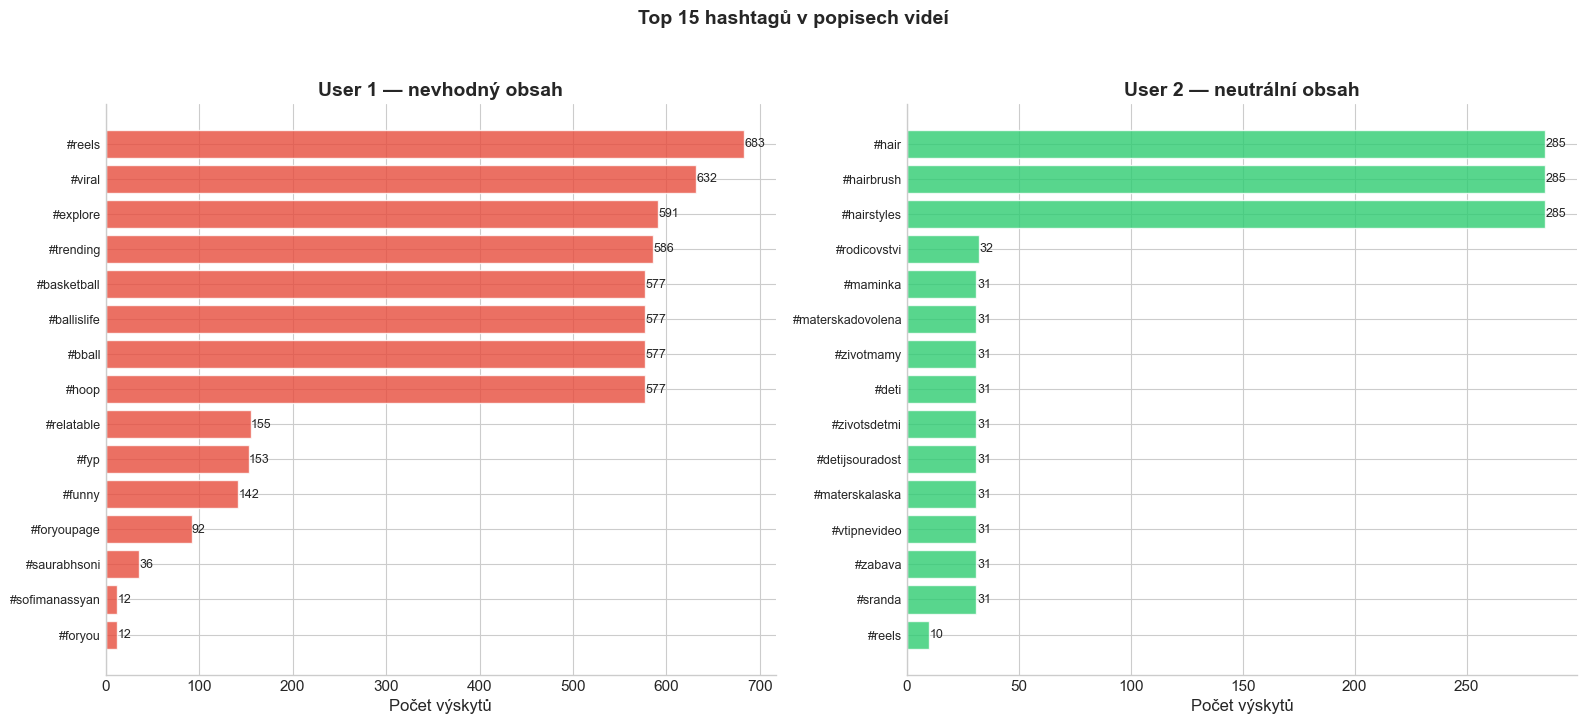

In [21]:
def extract_hashtags(descriptions):
    tags = []
    for desc in descriptions.dropna():
        found = re.findall(r'#([\w]+)', str(desc).lower())
        tags.extend(found)
    return Counter(tags)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for idx, (df, label, color) in enumerate([
    (df1, 'User 1 — nevhodný obsah', COLORS['user1']),
    (df2, 'User 2 — neutrální obsah', COLORS['user2'])
]):
    ax = axes[idx]
    
    hashtags = extract_hashtags(df['video_description']).most_common(15)
    
    if hashtags:
        tags, counts = zip(*hashtags)
        bars = ax.barh(range(len(tags)), counts, color=color, alpha=0.8, edgecolor='white')
        ax.set_yticks(range(len(tags)))
        ax.set_yticklabels([f'#{t}' for t in tags], fontsize=9)
        ax.invert_yaxis()
        
        for bar, val in zip(bars, counts):
            ax.text(val + 0.3, bar.get_y() + bar.get_height()/2, str(val),
                    va='center', fontsize=9)
    
    ax.set_xlabel('Počet výskytů')
    ax.set_title(label, fontweight='bold')

plt.suptitle('Top 15 hashtagů v popisech videí', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('output/17_hashtags.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

---
# 14. SOUHRN A KLÍČOVÉ INSIGHTS
---

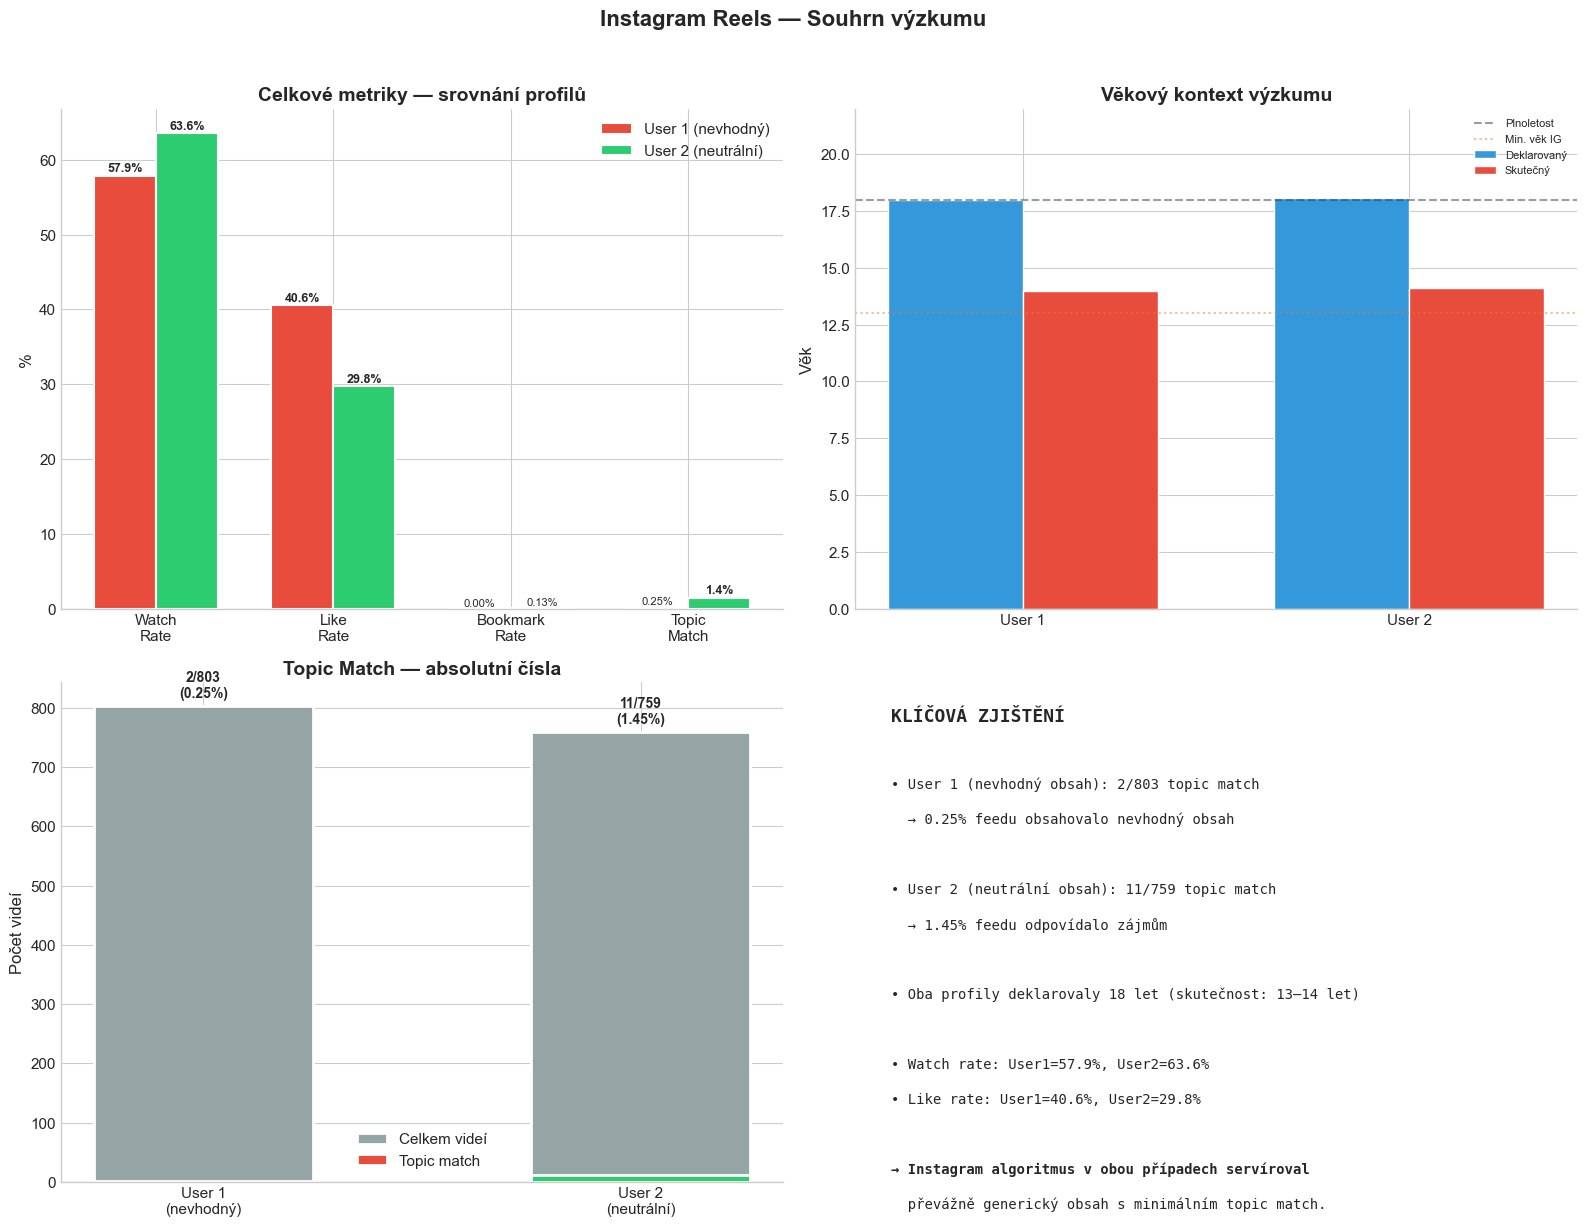


✓ VŠECHNY GRAFY BYLY ULOŽENY DO SLOŽKY 'output/'


In [22]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# === Panel 1: Celkové metriky srovnání ===
ax = axes[0, 0]
metrics_names = ['Watch\nRate', 'Like\nRate', 'Bookmark\nRate', 'Topic\nMatch']
vals_u1 = [df1['video_action_watch'].mean()*100, df1['video_action_like'].mean()*100,
           df1['video_action_bookmark'].mean()*100, df1['is_topic_match'].mean()*100]
vals_u2 = [df2['video_action_watch'].mean()*100, df2['video_action_like'].mean()*100,
           df2['video_action_bookmark'].mean()*100, df2['is_topic_match'].mean()*100]

x = np.arange(len(metrics_names))
width = 0.35
bars1 = ax.bar(x - width/2, vals_u1, width, label='User 1 (nevhodný)', color=COLORS['user1'],
               edgecolor='white', linewidth=1.5)
bars2 = ax.bar(x + width/2, vals_u2, width, label='User 2 (neutrální)', color=COLORS['user2'],
               edgecolor='white', linewidth=1.5)

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        if h > 0.5:
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.5, f'{h:.1f}%',
                    ha='center', fontsize=9, fontweight='bold')
        else:
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.3, f'{h:.2f}%',
                    ha='center', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(metrics_names)
ax.set_ylabel('%')
ax.set_title('Celkové metriky — srovnání profilů', fontweight='bold')
ax.legend()

# === Panel 2: Věkový kontext ===
ax = axes[0, 1]
age_data = {
    'Deklarovaný věk\n(rok 2008)': [18.0, 18.1],
    'Skutečný věk\n(rok 2012)': [14.0, 14.1]
}
x2 = np.arange(2)
width2 = 0.35
bars_d = ax.bar(x2 - width2/2, [18.0, 18.1], width2, label='Deklarovaný', color='#3498db')
bars_r = ax.bar(x2 + width2/2, [14.0, 14.1], width2, label='Skutečný', color='#e74c3c')
ax.axhline(y=18, color='#2c3e50', linestyle='--', alpha=0.5, label='Plnoletost')
ax.axhline(y=13, color='#e67e22', linestyle=':', alpha=0.5, label='Min. věk IG')
ax.set_xticks(x2)
ax.set_xticklabels(['User 1', 'User 2'])
ax.set_ylabel('Věk')
ax.set_title('Věkový kontext výzkumu', fontweight='bold')
ax.legend(fontsize=8)
ax.set_ylim(0, 22)

# === Panel 3: Topic match detail ===
ax = axes[1, 0]
match_data = {
    'User 1\n(nevhodný)': df1['is_topic_match'].sum(),
    'User 2\n(neutrální)': df2['is_topic_match'].sum()
}
total_data = {
    'User 1\n(nevhodný)': len(df1),
    'User 2\n(neutrální)': len(df2)
}
bars_total = ax.bar(match_data.keys(), total_data.values(), color=COLORS['random'],
                    edgecolor='white', linewidth=2, width=0.5, label='Celkem videí')
bars_match = ax.bar(match_data.keys(), match_data.values(), color=[COLORS['user1'], COLORS['user2']],
                    edgecolor='white', linewidth=2, width=0.5, label='Topic match')

for bar, val, total in zip(bars_match, match_data.values(), total_data.values()):
    ax.text(bar.get_x() + bar.get_width()/2, total + 15,
            f'{val}/{total}\n({val/total*100:.2f}%)',
            ha='center', fontweight='bold', fontsize=10)

ax.set_ylabel('Počet videí')
ax.set_title('Topic Match — absolutní čísla', fontweight='bold')
ax.legend()

# === Panel 4: Key finding text ===
ax = axes[1, 1]
ax.axis('off')

findings = [
    "KLÍČOVÁ ZJIŠTĚNÍ",
    "",
    f"• User 1 (nevhodný obsah): {df1['is_topic_match'].sum()}/{len(df1)} topic match",
    f"  → {df1['is_topic_match'].mean()*100:.2f}% feedu obsahovalo nevhodný obsah",
    "",
    f"• User 2 (neutrální obsah): {df2['is_topic_match'].sum()}/{len(df2)} topic match",
    f"  → {df2['is_topic_match'].mean()*100:.2f}% feedu odpovídalo zájmům",
    "",
    "• Oba profily deklarovaly 18 let (skutečnost: 13–14 let)",
    "",
    f"• Watch rate: User1={df1['video_action_watch'].mean()*100:.1f}%, "
    f"User2={df2['video_action_watch'].mean()*100:.1f}%",
    f"• Like rate: User1={df1['video_action_like'].mean()*100:.1f}%, "
    f"User2={df2['video_action_like'].mean()*100:.1f}%",
    "",
    "→ Instagram algoritmus v obou případech servíroval",
    "  převážně generický obsah s minimálním topic match."
]

for i, line in enumerate(findings):
    weight = 'bold' if i == 0 or line.startswith('→') else 'normal'
    size = 13 if i == 0 else 10
    ax.text(0.05, 0.95 - i*0.07, line, transform=ax.transAxes,
            fontsize=size, fontweight=weight, verticalalignment='top',
            fontfamily='monospace')

plt.suptitle('Instagram Reels — Souhrn výzkumu', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('output/18_summary_insights.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print("\n" + "=" * 80)
print("✓ VŠECHNY GRAFY BYLY ULOŽENY DO SLOŽKY 'output/'")
print("=" * 80)

---
# 15. ZÁVĚR

Analýza ukazuje, že Instagram Reels algoritmus u obou syntetických profilů (nezletilý uživatel hledající nevhodný obsah i kontrolní profil s neutrálními zájmy) servíroval **převážně generický/náhodný obsah**. Topic match se vyskytl pouze ve zlomku případů.

**Interpretace pro výzkum:**
- Nízká míra topic match u User 1 naznačuje, že Instagram **neeskaluje** nevhodný obsah směrem k nezletilým uživatelům, a to ani v případě, kdy uživatel aktivně tento obsah vyhledával.
- Srovnání s User 2 poskytuje kontrolní baseline — i u neutrálních témat je míra personalizace velmi nízká.
- Diskrepance deklarovaného a skutečného věku poukazuje na **nedostatečnou verifikaci věku** na platformě.

*Tento notebook byl vytvořen v rámci výzkumu algoritmického auditu sociálních sítí.*